# CNN Español Colombia — Bronze → Silver → Gold → Grafo de dependencias

Laboratorio de ingesta y enriquecimiento. Las capas (ver `docs/arquitectura.md` §11):

| Capa | Qué | Quién | ¿LLM? |
|---|---|---|---|
| **BRONZE** | El HTML/RSS crudo tal cual llegó | `CNNColombiaFetcher` (descarga) | No |
| **SILVER** | `CNNArticle` parseado, deduplicado, fechas UTC | `CNNColombiaFetcher` (parsing determinista) | No |
| **GOLD** | 15 tópicos + canal de transmisión FX + entidades | `NewsAnalyzer` del pipeline (`gpt-5.4-mini` + `with_structured_output`) | **Sí — aquí empieza el costo** |

La taxonomía es **la misma del pipeline** (`cop_fx/contracts.py`) y tiene dos niveles:
- `topic`: qué ES la noticia — incluye `public_health`, `environment_climate`, `sports`, `security_conflict`, `labor_social`...
- `fx_relevance` + `fx_channel`: si transmite al USD/COP y POR QUÉ mecanismo — una sequía es `indirect` vía `inflation`; un partido de fútbol es `none` y **pesa cero en la señal por contrato**.

> La frontera de capa es el momento en que un LLM toca el dato: si mañana mejoras el prompt, reprocesas GOLD desde SILVER sin re-scrapear.

**Prerequisito**: `OPENAI_API_KEY` en el `.env` de la raíz del proyecto (el mismo que usa el pipeline).

## 0. Entorno — cargar `.env` y validar claves

In [1]:
# DEBE IR PRIMERO — carga las variables del .env antes de cualquier import de cop_fx
import os
from dotenv import load_dotenv

load_dotenv()  # lee .env desde la raíz del proyecto (jupyter.notebookFileRoot = workspaceFolder)

api_key = os.getenv("OPENAI_API_KEY", "")
if not api_key or api_key.startswith("sk-ant-..."):
    raise EnvironmentError(
        "OPENAI_API_KEY no encontrada.\n"
        "Edita el archivo .env en la raíz del proyecto y agrega tu clave real."
    )
print(f"✓ OPENAI_API_KEY cargada ({api_key[:12]}...)")

✓ OPENAI_API_KEY cargada (sk-proj-s76m...)


In [2]:
import json
import sqlite3
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

from cop_fx.data.cnn_fetcher import CNNArticle, CNNColombiaFetcher

# Raíz del repo, sin importar desde dónde corra el kernel
ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
DB_PATH = ROOT / "data" / "cnn_articles.db"
DB_PATH.parent.mkdir(exist_ok=True)
print(f"Base de datos: {DB_PATH.resolve()}")

Base de datos: /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data/cnn_articles.db


## 1. BRONZE → SILVER — Scraping CNN Colombia

El fetcher descarga el feed/HTML crudo (Bronze) y lo parsea de forma **determinista** a `CNNArticle` (Silver): sin LLM, sin grafo, cero tokens. En la Fase 1 del roadmap el crudo se persistirá a disco *antes* de parsear, para poder reprocesar sin re-scrapear.

In [3]:
fetcher = CNNColombiaFetcher(max_articles=30)

# enrich_authors=True → hace 1 request por artículo para obtener el autor real
articles: list[CNNArticle] = fetcher.fetch(enrich_authors=True)

print(f"\nArtículos obtenidos : {len(articles)}")
print(f"Con autor           : {sum(1 for a in articles if a.author)}")

12:50:24  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: starting (max=30)


12:50:24  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/colombia/feed/


12:50:24  WARNING   cop_fx.data.cnn_fetcher  —  Colombia RSS empty — trying main CNN Español feed


12:50:25  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/feed/


12:50:25  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: fetched 3437430 bytes from https://cnnespanol.cnn.com/colombia/


...

12:50:41  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: fetched 3481481 bytes from https://cnnespanol.cnn.com/2026/05/31/deportes/uzbekistan-debut-colombia-mundial-2026-orix


12:50:42  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: fetched 3445523 bytes from https://cnnespanol.cnn.com/2026/05/31/colombia/elecciones-cepeda-de-la-espriella-segunda-vuelta-orix


12:50:42  SUCCESS   cop_fx.data.cnn_fetcher  —  Author enrichment: 30/30 filled


12:50:42  SUCCESS   cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: 30 unique articles ready | with author: 30/30



Artículos obtenidos : 30
Con autor           : 30


In [4]:
df_raw = pd.DataFrame([
    {
        "fecha"  : a.published_at.strftime("%Y-%m-%d"),
        "título" : a.title,
        "autor"  : a.author or "(sin autor)",
        "url"    : a.url,
    }
    for a in articles
])
df_raw

,fecha,título,autor,url
0,2026-06-11,La fallida suspensión temporal de Petro y sus ...,Fernando Ramos,https://cnnespanol.cnn.com/2026/06/11/colombia...
1,2026-06-11,Apartan del cargo a congresista oficialista qu...,EFE,https://cnnespanol.cnn.com/2026/06/11/colombia...
2,2026-06-11,"Según la audiencia de CNN, esta selección gana...",Federico Leiva,https://cnnespanol.cnn.com/2026/06/11/deportes...
3,2026-06-11,Así fue la impresionante recepción en México l...,CNN en Español,https://cnnespanol.cnn.com/2026/06/11/colombia...
4,2026-06-11,El Gobierno de Trump impidió un encuentro entr...,CNN en Español,https://cnnespanol.cnn.com/2026/06/11/colombia...
5,2026-06-10,"Ordenan ""suspensión provisional"" de Petro hast...",CNN Español,https://cnnespanol.cnn.com/2026/06/10/colombia...
6,2026-06-08,"Quién es Richard Ríos, jugador de Colombia: tr...",Luis Quintana,https://cnnespanol.cnn.com/2026/06/08/deportes...
7,2026-06-08,Cepeda se diferencia de Petro y reconoce los r...,EFE,https://cnnespanol.cnn.com/2026/06/08/colombia...
8,2026-06-06,Perú tardó semanas en dar resultados; Colombia...,Mauricio Torres,https://cnnespanol.cnn.com/2026/06/06/latinoam...
9,2026-06-05,¿Por qué se le prohibió a Abelardo de la Espri...,Stefano Pozzebon,https://cnnespanol.cnn.com/2026/06/05/colombia...


## 2. GOLD — Análisis enriquecido con el `NewsAnalyzer` del pipeline

Una sola llamada estructurada produce, **por artículo**: `topic` (15 dominios), `keywords`, `entities` (personas/instituciones/empresas/lugares), `fx_relevance` (direct / indirect / none), `fx_channel` (tasas, inflación, términos de intercambio, riesgo país, flujos, crecimiento), `severity`, `bullish_cop` y `reasoning` — más la narrativa FX del día.

El contrato Pydantic garantiza coherencia: si `fx_relevance="none"`, el validador fuerza `fx_channel="none"` y `severity="low"`. Una noticia de deportes no puede contaminar la señal ni aunque el modelo se equivoque.

In [5]:
from cop_fx.analysis.news_analyzer import NewsAnalyzer

# El MISMO analyzer del pipeline: gpt-5.4-mini (tier 'fast') + BatchAnalysis.
# CNNArticle expone .title y .summary — sirve para cualquier fuente sin adaptadores.
analyzer = NewsAnalyzer()
analysis = analyzer.analyze(articles)

print(f"✓ {len(analysis.items)} artículos analizados\n")
print(f"Narrativa FX del día:\n{analysis.narrative}")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


✓ 30 artículos analizados

Narrativa FX del día:
El lote está dominado por noticias electorales colombianas, por lo que el sesgo FX es de mayor volatilidad y prima de riesgo. Las notas relevantes apuntan a un repunte de incertidumbre política, cuestionamientos a resultados y escalada hacia segunda vuelta, todo vía channel country_risk. Las piezas deportivas no aportan señal macro; el COP queda vulnerable si la narrativa electoral se deteriora más.


In [6]:
df = pd.DataFrame([
    {
        "title"       : it.article.title,
        "author"      : it.article.author,
        "published_at": it.article.published_at.isoformat(),
        "summary"     : it.article.summary,
        "url"         : it.article.url,
        "source"      : it.article.source,
        "topic"       : it.topic,
        "keywords"    : json.dumps(it.keywords, ensure_ascii=False),
        "entities"    : json.dumps(it.entities, ensure_ascii=False),
        "fx_relevance": it.fx_relevance,
        "fx_channel"  : it.fx_channel,
        "severity"    : it.severity,
        "bullish_cop" : int(it.bullish_cop),
        "reasoning"   : it.reasoning,
        "fetched_at"  : datetime.now(tz=timezone.utc).isoformat(),
    }
    for it in analysis.items
])
print(f"✓ {len(df)} filas GOLD")
df[["title", "topic", "fx_relevance", "fx_channel", "severity", "bullish_cop"]]

✓ 30 filas GOLD


,title,topic,fx_relevance,fx_channel,severity,bullish_cop
0,La fallida suspensión temporal de Petro y sus ...,political_risk,indirect,country_risk,high,0
1,Apartan del cargo a congresista oficialista qu...,political_risk,indirect,country_risk,medium,0
2,"Según la audiencia de CNN, esta selección gana...",sports,none,none,low,0
3,Así fue la impresionante recepción en México l...,sports,none,none,low,0
4,El Gobierno de Trump impidió un encuentro entr...,political_risk,indirect,country_risk,low,0
5,"Ordenan ""suspensión provisional"" de Petro hast...",political_risk,indirect,country_risk,high,0
6,"Quién es Richard Ríos, jugador de Colombia: tr...",sports,none,none,low,0
7,Cepeda se diferencia de Petro y reconoce los r...,political_risk,indirect,country_risk,medium,0
8,Perú tardó semanas en dar resultados; Colombia...,political_risk,none,none,low,0
9,¿Por qué se le prohibió a Abelardo de la Espri...,sports,none,none,low,0


In [7]:
# ¿Cuánta señal FX hay realmente en un día de CNN Colombia?
# Esta tabla ES el argumento del router (Etapa 2): la mayoría del día es ruido FX.
pd.crosstab(df["topic"], df["fx_relevance"], margins=True)

fx_relevance,indirect,none,All
topic,,,
political_risk,19,1,20
sports,0,10,10
All,19,11,30


## 3. Grafo de dependencias — tópicos ↔ entidades

Grafo bipartito: cada tópico se conecta con las entidades que sus noticias mencionan; el peso de la arista es el número de co-menciones. Sobre él corremos **detección de comunidades** (greedy modularity).

Por qué importa: las comunidades son los **clusters naturales del día** — exactamente la unidad de trabajo que el orchestrator de la Etapa 3 despacha con `Send` (un worker por cluster). Si una entidad puentea dos tópicos (p. ej. *Petro* aparece en `political_risk` y en `fiscal_policy`), eso es señal de una historia transversal que un análisis por-artículo no ve.

Nodos: 20 | Aristas: 20 | Comunidades: 2
Entidades-puente entre tópicos: ['● Colombia', '● Abelardo de la Espriella']


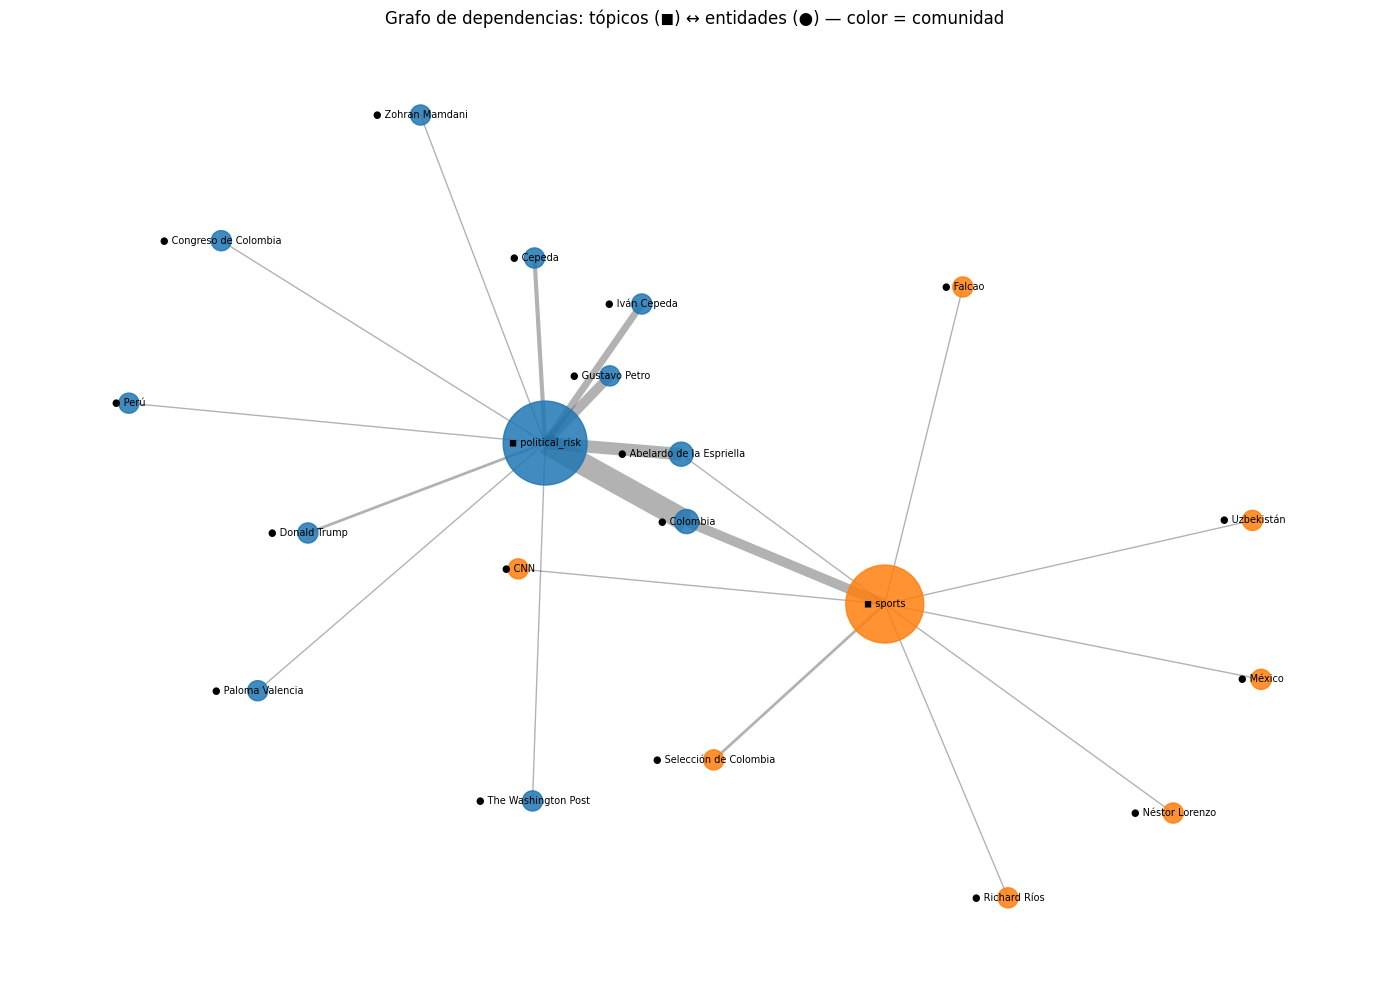

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

G = nx.Graph()
for it in analysis.items:
    t = f"◼ {it.topic}"
    G.add_node(t, kind="topic")
    for e in it.entities:
        en = f"● {e}"
        G.add_node(en, kind="entity")
        w = (G.get_edge_data(t, en) or {}).get("weight", 0)
        G.add_edge(t, en, weight=w + 1)

communities = list(greedy_modularity_communities(G, weight="weight"))
print(f"Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()} | Comunidades: {len(communities)}")

# Entidades-puente: tocan más de un tópico → historias transversales
bridges = [
    n for n in G.nodes
    if G.nodes[n]["kind"] == "entity"
    and len({nb for nb in G.neighbors(n) if G.nodes[nb]["kind"] == "topic"}) > 1
]
print(f"Entidades-puente entre tópicos: {bridges}")

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.65, seed=42, weight="weight")
palette = plt.cm.tab10.colors
node_color = [
    palette[next(ci for ci, c in enumerate(communities) if n in c) % 10] for n in G.nodes
]
sizes = [
    900 + 250 * G.degree(n) if G.nodes[n]["kind"] == "topic" else 120 + 90 * G.degree(n)
    for n in G.nodes
]
nx.draw_networkx_edges(G, pos, alpha=0.3, width=[G[u][v]["weight"] for u, v in G.edges], ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title("Grafo de dependencias: tópicos (◼) ↔ entidades (●) — color = comunidad")
ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Señal direccional por cluster de tópico — el mismo cálculo determinista
# que aggregate_signals ejecuta dentro del grafo (cero LLM).
from cop_fx.contracts import ArticleAnalysis, aggregate_news_signal


def to_contract(items: list) -> list[ArticleAnalysis]:
    return [
        ArticleAnalysis(
            index=i,
            topic=it.topic,
            keywords=it.keywords or ["sin_clasificar"],
            entities=it.entities,
            fx_relevance=it.fx_relevance,
            fx_channel=it.fx_channel,
            severity=it.severity,
            bullish_cop=it.bullish_cop,
            reasoning=it.reasoning[:240],
        )
        for i, it in enumerate(items)
    ]


clusters: dict[str, list] = {}
for it in analysis.items:
    clusters.setdefault(it.topic, []).append(it)

rows = []
for topic, items in sorted(clusters.items(), key=lambda kv: -len(kv[1])):
    sig = aggregate_news_signal(to_contract(items))
    rows.append({
        "cluster": topic,
        "artículos": len(items),
        "score": sig.score,
        "dirección": sig.direction,
    })

global_sig = aggregate_news_signal(
    to_contract(analysis.items),
    {i: it.article.title for i, it in enumerate(analysis.items)},
)
print(f"SEÑAL GLOBAL: {global_sig.direction} (score={global_sig.score})")
print(f"Drivers: {global_sig.drivers}\n")
pd.DataFrame(rows)

SEÑAL GLOBAL: up (score=-6.7)
Drivers: ['La fallida suspensión temporal de Petro y sus efectos en la segunda vuelta electoral en Colombia', 'Ordenan "suspensión provisional" de Petro hasta después de elecciones; el presidente de Colombia dice que "no es así"', 'Segunda vuelta en Colombia: alianzas, estrategia y disputa por el voto decisivo', 'Petro insiste en su denuncia de fraude en Colombia, pero observadores electorales aseguran que no detectan irregularidades', 'Colombia va a una segunda vuelta presidencial entre De la Espriella y Cepeda: así reacciona la región', 'Colombia votó pese a la violencia que marcó las campañas electorales', 'Colombia define a sus finalistas electorales: De la Espriella y Cepeda irán al balotaje', 'De la Espriella da un batacazo en Colombia, pero Cepeda y Petro cuestionan los resultados preliminares', 'De la Espriella y Cepeda pasan a segunda vuelta en Colombia']



,cluster,artículos,score,dirección
0,political_risk,20,-6.7,up
1,sports,10,0.0,neutral


## 4. En vivo: la rama de noticias del grafo real (Etapas 2 + 3)

Este es el subgrafo de noticias del pipeline (`src/cop_fx/agents/graph.py`) con sus **nodos reales**, corriendo sobre los artículos de hoy:

1. `check_materiality` — una llamada barata decide si hay señal FX **y de paso etiqueta cada titular** (esos tags siembran los clusters: cero costo extra).
2. Router condicional: día sin señal → `skip_news` (cero tokens más); día con señal → `orchestrate`.
3. `orchestrate` + **`Send`** — fan-out dinámico: un `topic_worker` por cluster, todos en paralelo en el mismo superstep.
4. `aggregate_signals` — consolida los workers en una señal direccional, determinista.

Esto es el patrón **orchestrator-workers** que tu curso no cubre: la cantidad de workers la decide el dato, no el grafo.

In [10]:
from langgraph.graph import END, START, StateGraph

from cop_fx.agents import nodes as N
from cop_fx.agents.state import PipelineState

g = StateGraph(PipelineState)
g.add_node("check_materiality", N.check_materiality)
g.add_node("skip_news", N.skip_news)
g.add_node("orchestrate", N.orchestrate)
g.add_node("topic_worker", N.topic_worker)
g.add_node("aggregate_signals", N.aggregate_signals)

g.add_edge(START, "check_materiality")
g.add_conditional_edges(
    "check_materiality",
    N.route_materiality,
    {"orchestrate": "orchestrate", "skip_news": "skip_news"},
)
g.add_conditional_edges("orchestrate", N.fan_out_clusters, ["topic_worker"])
g.add_edge("topic_worker", "aggregate_signals")
g.add_edge("aggregate_signals", END)
g.add_edge("skip_news", END)

news_branch = g.compile()
print(news_branch.get_graph().draw_mermaid())

result = news_branch.invoke({"raw_articles": articles, "errors": []})

print(f"¿Material?: {result.get('has_material_news')} — {result.get('materiality_reason')}\n")
print(f"Clusters despachados: { {t: len(i) for t, i in result.get('clusters', {}).items()} }\n")
print(f"Señal de noticias: {result.get('news_signal')}\n")
print("Narrativas por cluster:")
print(result.get("news_summary", ""))

Importing plotly failed. Interactive plots will not work.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	check_materiality(check_materiality)
	skip_news(skip_news)
	orchestrate(orchestrate)
	topic_worker(topic_worker)
	aggregate_signals(aggregate_signals)
	__end__([<p>__end__</p>]):::last
	__start__ --> check_materiality;
	check_materiality -.-> orchestrate;
	check_materiality -.-> skip_news;
	orchestrate -.-> topic_worker;
	topic_worker --> aggregate_signals;
	aggregate_signals --> __end__;
	skip_news --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



12:51:02  INFO      cop_fx.agents.nodes  —  Materiality gate: True — Sí hay noticia material para USD/COP hoy: abundan titulares sobre la segunda vuelta presidencial en Colombia, denuncias de fraude, violencia electoral, alianzas políticas y respaldo de Trump, todos canales directos de riesgo país y prima de incertidumbre que pueden mover el peso. Los titulares de la


12:51:02  INFO      cop_fx.agents.nodes  —  Orchestrator: 1 clusters → {'political_risk': 19}


12:51:11  INFO      cop_fx.agents.nodes  —  topic_worker[political_risk]: 19 artículos analizados


12:51:11  INFO      cop_fx.agents.nodes  —  Señal de noticias: up (score=-2.55, drivers=0)


¿Material?: True — Sí hay noticia material para USD/COP hoy: abundan titulares sobre la segunda vuelta presidencial en Colombia, denuncias de fraude, violencia electoral, alianzas políticas y respaldo de Trump, todos canales directos de riesgo país y prima de incertidumbre que pueden mover el peso. Los titulares de la

Clusters despachados: {'political_risk': 19}

Señal de noticias: {'direction': 'up', 'score': -2.55, 'drivers': []}

Narrativas por cluster:
[political_risk] El sesgo FX del día es ligeramente negativo para el COP por la mayor incertidumbre política y electoral en Colombia. Los titulares sobre disputas de resultados, denuncias de fraude y tensiones institucionales elevan la prima de riesgo vía country risk. No obstante, gran parte de la información es ya conocida o de campaña, por lo que el impacto agregador parece más bien moderado.


## 5. Base de datos SQLite — upsert con el esquema enriquecido

El esquema GOLD creció (`entities`, `fx_relevance`, `fx_channel`, `severity`, `bullish_cop`, `reasoning`). Dos detalles de ingeniería:

- **Migración liviana**: si la tabla existe con el esquema viejo, se agregan las columnas faltantes con `ALTER TABLE` (sin perder datos).
- **Upsert por URL**: si el artículo ya existía, se **refresca su enriquecimiento** — así puedes mejorar el prompt y reprocesar GOLD sobre los mismos artículos.

In [11]:
GOLD_COLS = {
    "entities": "TEXT",
    "fx_relevance": "TEXT",
    "fx_channel": "TEXT",
    "severity": "TEXT",
    "bullish_cop": "INTEGER",
    "reasoning": "TEXT",
}


def save_to_sqlite(df: pd.DataFrame, db_path: Path) -> tuple[int, int]:
    """Upsert por URL. Devuelve (insertados, actualizados)."""
    conn = sqlite3.connect(db_path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS articles (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            title        TEXT    NOT NULL,
            author       TEXT,
            published_at TEXT,
            summary      TEXT,
            url          TEXT    UNIQUE NOT NULL,
            source       TEXT,
            topic        TEXT,
            keywords     TEXT,
            fetched_at   TEXT
        )
    """)
    # Migración liviana: agrega columnas GOLD nuevas si faltan
    existing = {row[1] for row in conn.execute("PRAGMA table_info(articles)")}
    for col, sql_type in GOLD_COLS.items():
        if col not in existing:
            conn.execute(f"ALTER TABLE articles ADD COLUMN {col} {sql_type}")
    conn.commit()

    before = conn.execute("SELECT COUNT(*) FROM articles").fetchone()[0]
    for _, row in df.iterrows():
        conn.execute(
            """
            INSERT INTO articles
                (title, author, published_at, summary, url, source, topic, keywords,
                 entities, fx_relevance, fx_channel, severity, bullish_cop, reasoning,
                 fetched_at)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            ON CONFLICT(url) DO UPDATE SET
                topic        = excluded.topic,
                keywords     = excluded.keywords,
                entities     = excluded.entities,
                fx_relevance = excluded.fx_relevance,
                fx_channel   = excluded.fx_channel,
                severity     = excluded.severity,
                bullish_cop  = excluded.bullish_cop,
                reasoning    = excluded.reasoning,
                fetched_at   = excluded.fetched_at
            """,
            (
                row["title"], row["author"], row["published_at"], row["summary"],
                row["url"], row["source"], row["topic"], row["keywords"],
                row["entities"], row["fx_relevance"], row["fx_channel"],
                row["severity"], row["bullish_cop"], row["reasoning"],
                row["fetched_at"],
            ),
        )
    conn.commit()
    after = conn.execute("SELECT COUNT(*) FROM articles").fetchone()[0]
    conn.close()
    inserted = after - before
    return inserted, len(df) - inserted


nuevos, refrescados = save_to_sqlite(df, DB_PATH)
print(f"✓ {nuevos} artículos nuevos | {refrescados} re-enriquecidos (upsert) en {DB_PATH}")

✓ 0 artículos nuevos | 30 re-enriquecidos (upsert) en /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data/cnn_articles.db


## 4. Consultar la base de datos

In [12]:
conn = sqlite3.connect(DB_PATH)

# Todos los artículos, con el enriquecimiento FX
df_db = pd.read_sql("SELECT * FROM articles ORDER BY published_at DESC", conn)
conn.close()

print(f"Total en la DB: {len(df_db)} artículos")
df_db[["title", "topic", "fx_relevance", "fx_channel", "severity", "entities"]]

Total en la DB: 31 artículos


,title,topic,fx_relevance,fx_channel,severity,entities
0,Apartan del cargo a congresista oficialista qu...,political_risk,indirect,country_risk,medium,"[""Gustavo Petro"", ""Congreso de Colombia""]"
1,"Según la audiencia de CNN, esta selección gana...",sports,none,none,low,"[""CNN""]"
2,Así fue la impresionante recepción en México l...,sports,none,none,low,"[""Colombia"", ""México""]"
3,El Gobierno de Trump impidió un encuentro entr...,political_risk,indirect,country_risk,low,"[""Donald Trump"", ""Gustavo Petro"", ""Zohran Mamd..."
4,La fallida suspensión temporal de Petro y sus ...,political_risk,indirect,country_risk,high,"[""Gustavo Petro"", ""Colombia""]"
5,"Ordenan ""suspensión provisional"" de Petro hast...",political_risk,indirect,country_risk,high,"[""Gustavo Petro"", ""Colombia""]"
6,"Quién es Richard Ríos, jugador de Colombia: tr...",sports,none,none,low,"[""Richard Ríos"", ""Selección de Colombia""]"
7,Cepeda se diferencia de Petro y reconoce los r...,political_risk,indirect,country_risk,medium,"[""Cepeda"", ""Gustavo Petro"", ""Colombia""]"
8,Perú tardó semanas en dar resultados; Colombia...,political_risk,none,none,low,"[""Perú"", ""Colombia""]"
9,¿Por qué se le prohibió a Abelardo de la Espri...,sports,none,none,low,"[""Abelardo de la Espriella"", ""Selección de Col..."


In [13]:
# Solo lo que tiene canal de transmisión al dólar — el "filtro de oro" del sistema
conn = sqlite3.connect(DB_PATH)
df_fx = pd.read_sql(
    """
    SELECT title, topic, fx_channel, severity, bullish_cop, reasoning
    FROM articles
    WHERE fx_relevance != 'none'
    ORDER BY CASE severity WHEN 'high' THEN 0 WHEN 'medium' THEN 1 ELSE 2 END
    """,
    conn,
)
conn.close()

print(f"Artículos con relevancia FX: {len(df_fx)} de {len(df_db)}")
df_fx

Artículos con relevancia FX: 19 de 31


,title,topic,fx_channel,severity,bullish_cop,reasoning
0,"Ordenan ""suspensión provisional"" de Petro hast...",political_risk,country_risk,high,0,Aumenta incertidumbre electoral; canal country...
1,"Segunda vuelta en Colombia: alianzas, estrateg...",political_risk,country_risk,high,0,Define incertidumbre electoral; canal country_...
2,Petro insiste en su denuncia de fraude en Colo...,political_risk,country_risk,high,0,Denuncia de fraude aumenta prima; canal countr...
3,Colombia va a una segunda vuelta presidencial ...,political_risk,country_risk,high,0,Mercado lee el balotaje vía country_risk y vol...
4,Colombia votó pese a la violencia que marcó la...,political_risk,country_risk,high,0,Violencia electoral eleva prima de riesgo; can...
5,Colombia define a sus finalistas electorales: ...,political_risk,country_risk,high,0,Confirmación del balotaje aumenta volatilidad;...
6,"De la Espriella da un batacazo en Colombia, pe...",political_risk,country_risk,high,0,Cuestionamientos a resultados disparan country...
7,De la Espriella y Cepeda pasan a segunda vuelt...,political_risk,country_risk,high,0,Balotaje incrementa incertidumbre; canal count...
8,La fallida suspensión temporal de Petro y sus ...,political_risk,country_risk,high,0,Eleva incertidumbre política y prima de riesgo...
9,Apartan del cargo a congresista oficialista qu...,political_risk,country_risk,medium,0,Más ruido institucional; canal country_risk co...


## 5. Exportar

In [14]:
export_path = ROOT / "data"

# CSV
csv_file = export_path / "cnn_articles.csv"
df_db.to_csv(csv_file, index=False)
print(f"✓ CSV  → {csv_file}")

# Parquet (más eficiente para subir a cloud / BigQuery)
parquet_file = export_path / "cnn_articles.parquet"
df_db.to_parquet(parquet_file, index=False)
print(f"✓ Parquet → {parquet_file}")

✓ CSV  → /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data/cnn_articles.csv
✓ Parquet → /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data/cnn_articles.parquet
